<a href="https://www.kaggle.com/code/salmamorsi/gen-alpha-mental-health-and-social-media?scriptVersionId=328707875" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv


In [23]:
import numpy as np

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv")

df.shape

(1200, 13)

In [3]:
df.head(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


## Percentage of Teens with depression 

In [4]:
df["depression_label"].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

In [5]:
percentage = df['depression_label'].value_counts(normalize=True)[1] * 100
print(f"Percentage of teens with depression in our date {round(percentage)} %")
print(f"the average age in our dataset {round(df["age"].mean())}")

Percentage of teens with depression in our date 3 %
the average age in our dataset 16


In [6]:
depressed_teens = df[df["depression_label"] == 1]

In [12]:
depressed_teens["age"].describe()

count    31.000000
mean     16.064516
std       2.064550
min      13.000000
25%      15.000000
50%      16.000000
75%      18.000000
max      19.000000
Name: age, dtype: float64

so now we know the average age for teens with depression is around 16 years old , and the youngest are 13 , the oldest are 19

In [8]:
import matplotlib.pyplot as plt


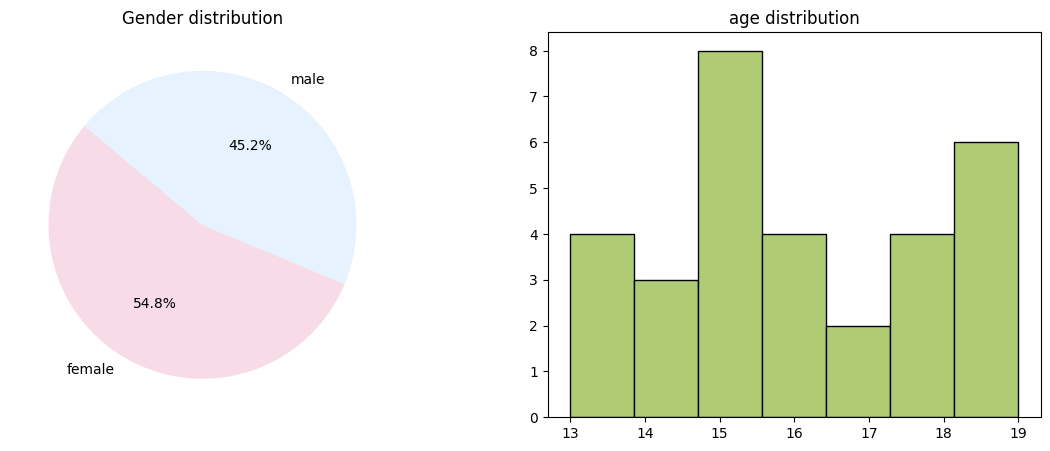

In [9]:

plt.rcParams['figure.figsize'] = [14, 5]
plt.subplot(1, 2, 1)

gender_counts  = depressed_teens["gender"].value_counts()
plt.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#F7DCE8', '#e6f3ff']  
)

plt.title("Gender distribution")
plt.subplot(1, 2, 2)


plt.hist(
    depressed_teens['age'], 
    bins=7,             
    color='#afcc75', 
    edgecolor='black'    
)

plt.title("age distribution")
plt.show()

# Social Media Usage Analysis

In [16]:
df.size

15600

In [22]:
result = (
    df.groupby('platform_usage')
    .agg(
        avg_daily_hours=('daily_social_media_hours', 'mean'),
        high_social_pct=('social_interaction_level',
                         lambda x: x.str.lower().eq('high').mean() * 100)
    )
    .reset_index()
)

result[['avg_daily_hours', 'high_social_pct']] = (
    result[['avg_daily_hours', 'high_social_pct']]
    .round(2)
)

print(result)

  platform_usage  avg_daily_hours  high_social_pct
0           Both             4.52            26.34
1      Instagram             4.56            33.09
2         TikTok             4.53            32.66


Instagram users recorded the highest average daily social media usage. However, the differences between platforms were relatively small, suggesting that users spend a similar amount of time on social media regardless of their preferred platform.

In [28]:
ct = pd.crosstab(df['platform_usage'], df['social_interaction_level'])
print(ct)

social_interaction_level  high  low  medium
platform_usage                             
Both                       103  144     144
Instagram                  136  120     155
TikTok                     130  151     117


In [63]:
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100
print(ct_percent)

social_interaction_level       high        low     medium
platform_usage                                           
Both                      26.342711  36.828645  36.828645
Instagram                 33.090024  29.197080  37.712895
TikTok                    32.663317  37.939698  29.396985


In [65]:
color_pallet =  [ "#001dff", "#0087ff" ,"#00fff6"]

In [66]:
ct_percent = ct_percent[['high', 'medium', 'low']]
print(ct_percent)


social_interaction_level       high     medium        low
platform_usage                                           
Both                      26.342711  36.828645  36.828645
Instagram                 33.090024  37.712895  29.197080
TikTok                    32.663317  29.396985  37.939698


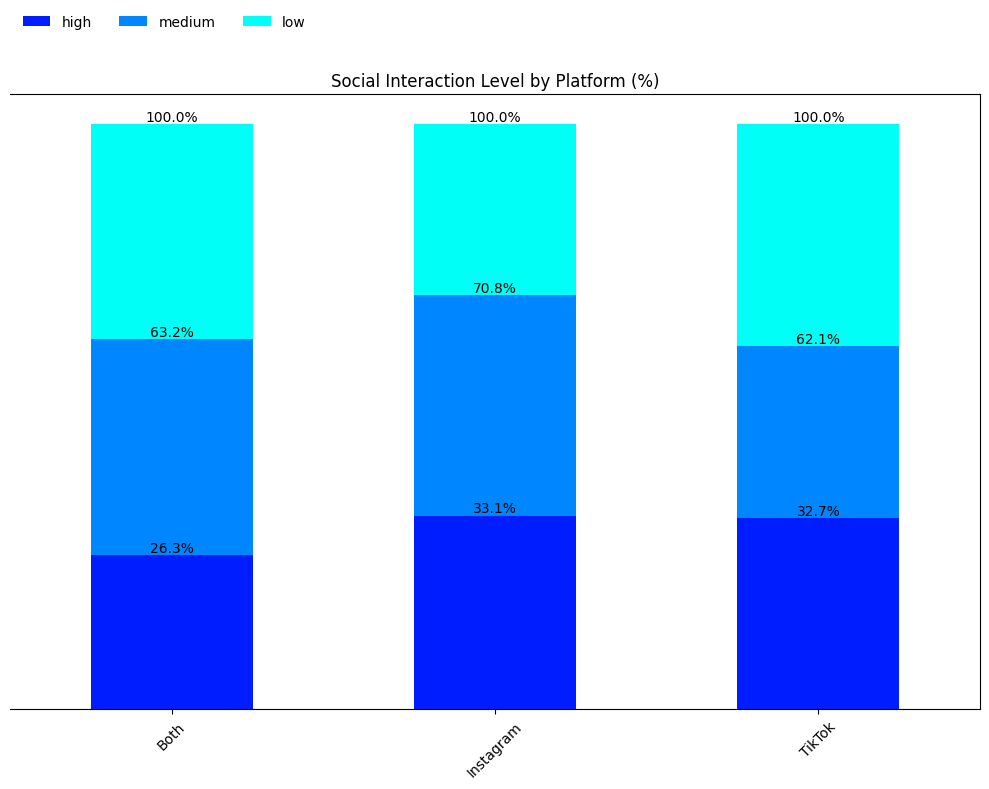

In [67]:
ax = ct_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10,8),
    title='Social Interaction Level by Platform (%)',
    color=color_pallet
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

ax.get_yaxis().set_visible(False)

ax.spines['left'].set_visible(False)


plt.xticks(rotation=45)

ax.legend(
    loc='upper left',
    ncol=3,
    bbox_to_anchor=(0, 1.15),  
    frameon=False
)
plt.xlabel(None)

plt.tight_layout()
plt.show()